## Import Necessary Libraries

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings(action="ignore")

In [2]:
cars_data=pd.read_csv("Cars.csv")
cars_data

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947
77,238,19.197888,115,150.576579,37.923113
78,263,34.000000,50,151.598513,15.769625
79,295,19.833733,119,167.944460,39.423099


## 3. Data Understanding

## 3.1 perform initial investigation on the data

In [3]:
cars_data.shape

(81, 5)

In [4]:
cars_data.isna().sum()

HP     0
MPG    0
VOL    0
SP     0
WT     0
dtype: int64

In [5]:
cars_data.dtypes

HP       int64
MPG    float64
VOL      int64
SP     float64
WT     float64
dtype: object

In [6]:
cars_data.describe()

,HP,MPG,VOL,SP,WT
count,81.000000,81.000000,81.000000,81.000000,81.000000
mean,117.469136,34.422076,98.765432,121.540272,32.412577
std,57.113502,9.131445,22.301497,14.181432,7.492813
min,49.000000,12.101263,50.000000,99.564907,15.712859
25%,84.000000,27.856252,89.000000,113.829145,29.591768
50%,100.000000,35.152727,101.000000,118.208698,32.734518
75%,140.000000,39.531633,113.000000,126.404312,37.392524
max,322.000000,53.700681,160.000000,169.598513,52.997752


## Now,lets check for the assumptions to perform liner regression

## 1. Linearity Test

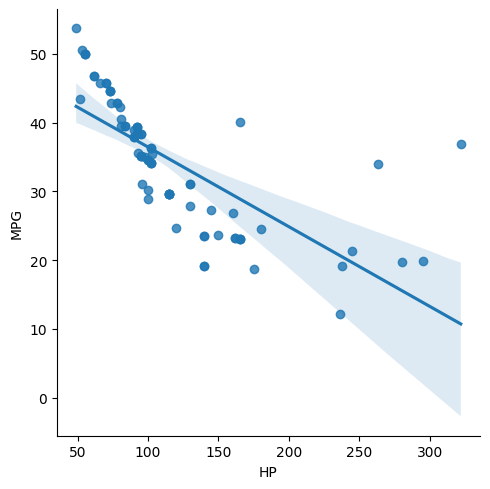

In [7]:
sns.lmplot(data=cars_data,x="HP",y="MPG")

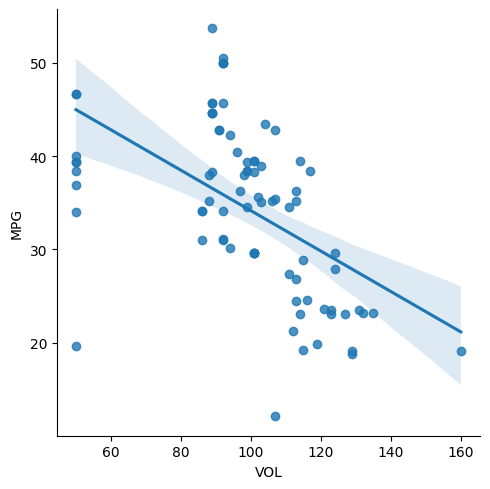

In [8]:
sns.lmplot(data=cars_data,x="VOL",y="MPG")

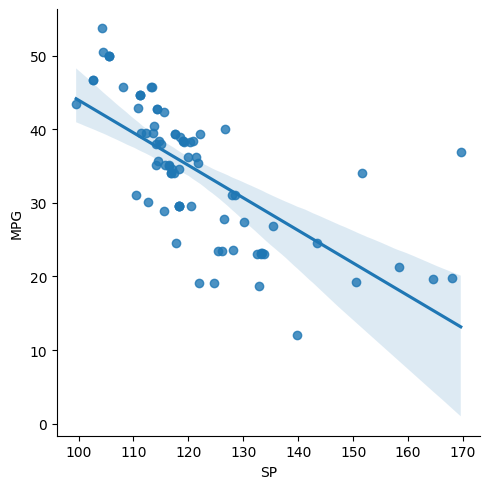

In [9]:
sns.lmplot(data=cars_data,x="SP",y="MPG")

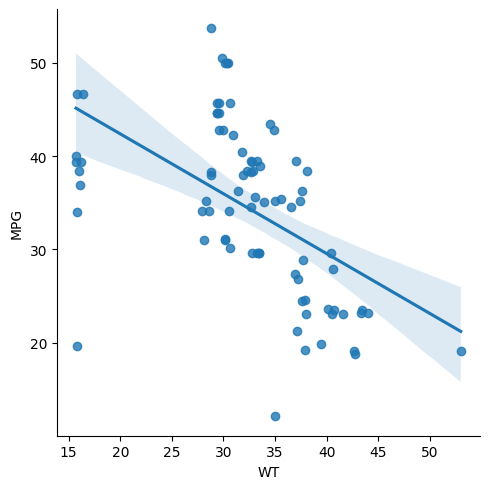

In [10]:
sns.lmplot(data=cars_data,x="WT",y="MPG")

###### RESULT - LINEARITY TEST FAILED

## TEST 2 - NORMALITY TEST

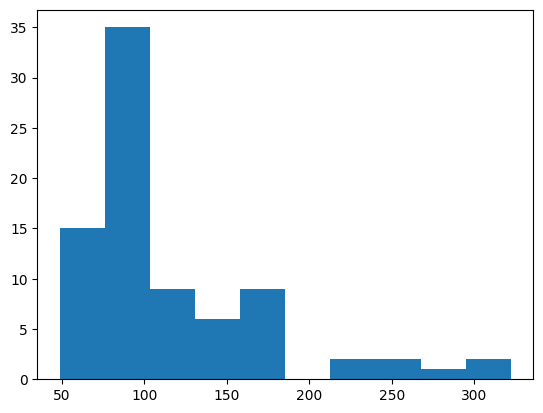

In [11]:
plt.hist(cars_data["HP"])
plt.show()

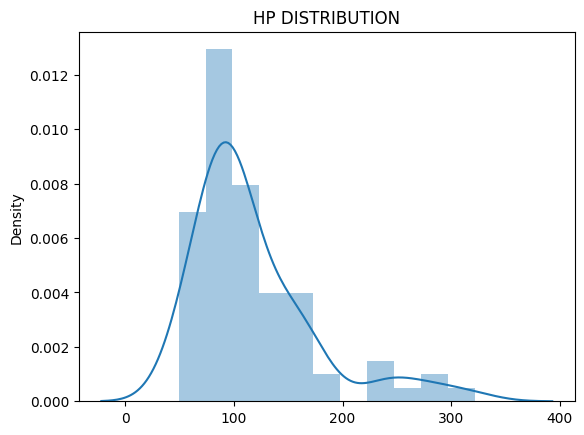

In [12]:
sns.distplot(x=cars_data["HP"])
plt.title("HP DISTRIBUTION")
plt.show()

(array([ 8., 12., 32., 10., 10.,  2.,  1.,  2.,  1.,  3.]),
 array([ 99.56490661, 106.56826723, 113.57162785, 120.57498847,
        127.57834909, 134.58170971, 141.58507032, 148.58843094,
        155.59179156, 162.59515218, 169.5985128 ]),
 <BarContainer object of 10 artists>)

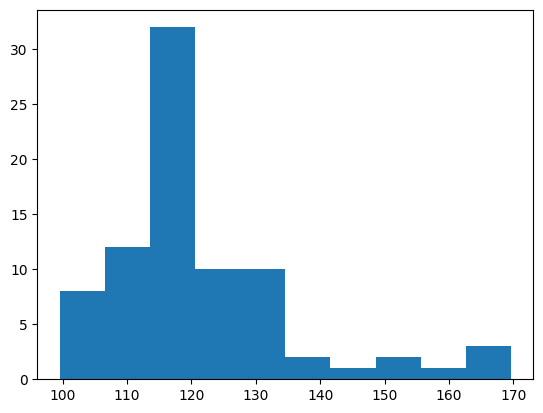

In [13]:
plt.hist(cars_data["SP"])

(array([ 9.,  0.,  0., 22., 20., 15.,  8.,  6.,  0.,  1.]),
 array([ 50.,  61.,  72.,  83.,  94., 105., 116., 127., 138., 149., 160.]),
 <BarContainer object of 10 artists>)

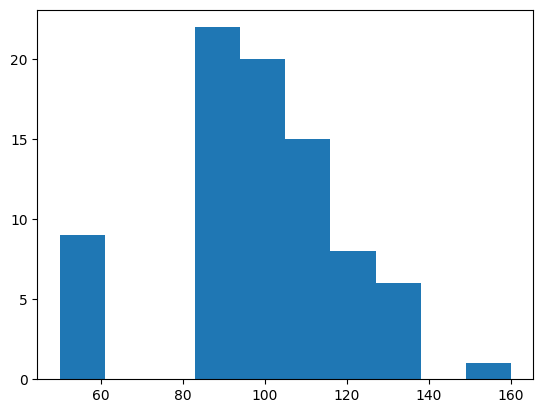

In [14]:
plt.hist(cars_data["VOL"])

(array([ 9.,  0.,  0., 22., 19., 18.,  7.,  5.,  0.,  1.]),
 array([15.71285853, 19.44134791, 23.1698373 , 26.89832668, 30.62681606,
        34.35530544, 38.08379483, 41.81228421, 45.54077359, 49.26926298,
        52.99775236]),
 <BarContainer object of 10 artists>)

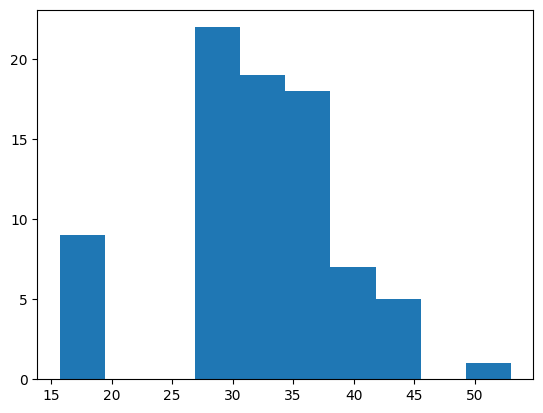

In [15]:
plt.hist(cars_data["WT"])

## TEST 2 ALSO FAILED

## TEST 3 multicollinrearity MATRIX TEST

In [16]:
corr_matrix=cars_data.corr()
corr_matrix

,HP,MPG,VOL,SP,WT
HP,1.000000,-0.725038,0.077459,0.973848,0.076513
MPG,-0.725038,1.000000,-0.529057,-0.687125,-0.526759
VOL,0.077459,-0.529057,1.000000,0.102170,0.999203
SP,0.973848,-0.687125,0.102170,1.000000,0.102439
WT,0.076513,-0.526759,0.999203,0.102439,1.000000


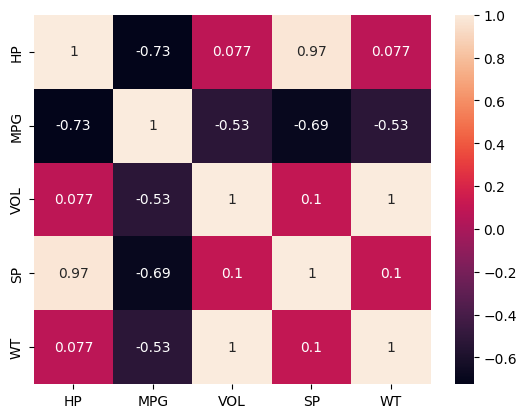

In [17]:
sns.heatmap(corr_matrix,annot=True)
plt.show()

In [18]:
### there is multicollinearity 

### test 4 autoregression passsed

In [20]:
## Data preparation

In [21]:
X=cars_data[["HP","VOL","SP","WT"]]
X

,HP,VOL,SP,WT
0,49,89,104.185353,28.762059
1,55,92,105.461264,30.466833
2,55,92,105.461264,30.193597
3,70,92,113.461264,30.632114
4,53,92,104.461264,29.889149
...,...,...,...,...
76,322,50,169.598513,16.132947
77,238,115,150.576579,37.923113
78,263,50,151.598513,15.769625
79,295,119,167.944460,39.423099


In [22]:
y = cars_data["MPG"]
y

0     53.700681
1     50.013401
2     50.013401
3     45.696322
4     50.504232
        ...    
76    36.900000
77    19.197888
78    34.000000
79    19.833733
80    12.101263
Name: MPG, Length: 81, dtype: float64

## Model Building

In [23]:
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.20,shuffle=True,random_state=22)

In [24]:
X_train

,HP,VOL,SP,WT
10,73,89,111.185353,29.363341
70,280,50,164.598513,15.823060
35,90,98,115.013085,31.911223
75,175,129,132.864163,42.778219
16,78,91,114.369293,29.535784
...,...,...,...,...
18,78,91,114.369293,29.929394
8,62,50,102.598513,16.359484
64,150,121,128.128401,40.159482
44,93,102,114.380966,33.078632


In [25]:
X_test

,HP,VOL,SP,WT
79,295,119,167.944460,39.423099
63,140,123,125.312342,40.722831
22,95,101,120.288996,32.675828
80,236,107,139.840817,34.948615
25,92,50,114.598513,16.043175
32,102,97,119.921115,31.380041
24,95,89,119.185353,28.781728
31,84,101,112.288996,33.234361
12,92,99,122.105055,32.813592
60,145,111,130.208698,36.888153


In [26]:
linear_model=LinearRegression()

In [27]:
## model training 

In [28]:
linear_model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [29]:
linear_model.intercept_

np.float64(40.94554500101247)

In [30]:
linear_model.coef_

array([-0.19044301, -0.10388321,  0.30952311, -0.34591175])

In [31]:
## model testing

In [32]:
y_predicted_train=linear_model.predict(X_train)
y_predicted_train

array([42.05491169, 27.9010042 , 38.18586099, 20.54412574, 41.82078364,
       27.13321864, 36.41233074, 33.59189495, 41.97148291, 43.07256386,
       25.54909869, 34.35834088, 21.34281989, 44.66687276, 39.12814818,
       27.75628049, 35.90333893, 42.58015474, 49.02834886, 38.82464211,
       41.04430184, 37.96989362, 33.59942211, 23.86005665, 26.29689682,
       38.07819186, 29.36670663, 29.45679928, 43.01778756, 36.86768587,
       33.67647645, 42.0496902 , 35.41837207, 49.18075303, 22.14021378,
       28.39125661, 37.7602834 , 34.33323189, 39.76678995, 17.93191498,
       32.70026746, 50.21860356, 23.32547362, 43.11230324, 24.68017233,
       38.18190083, 33.84231891, 38.86894962, 35.63001983, 22.59476984,
       38.64808194, 43.1662714 , 34.20635517, 17.16242149, 35.55247116,
       38.16209094, 35.97514664, 36.57922395, 42.46499958, 41.68462929,
       50.04159172, 25.57629063, 36.59952346, 43.28897826])

In [33]:
y_predicted_test=linear_model.predict(X_test)
y_predicted_test

array([10.74853513, 26.20644964, 38.29052702, 16.08032068, 48.15199372,
       37.70731903, 40.54253739, 37.71601182, 39.58408042, 29.34282893,
       39.12858647, 37.1349777 , 40.03214451, 35.48224721, 24.00831014,
       18.80204274, 39.22176165])

## model evaluation

In [35]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score

## Training Data

In [39]:
mean_absolute_error(y_train,y_predicted_train)

3.30491160991122

In [40]:
mean_squared_error(y_train,y_predicted_train)

19.71091889454513

In [41]:
root_mean_squared_error(y_train,y_predicted_train)

4.439698063443632

In [42]:
r2_score(y_train,y_predicted_train)

0.7623805317206689

In [43]:
import statsmodels.formula.api as smf

In [44]:
linear_stats_model=smf.ols(formula= "MPG~HP+VOL+WT+SP",data=cars_data).fit()
linear_stats_model

In [45]:
print("R2_score=",linear_stats_model.rsquared.round(4),"\nAdjusted_r2_score=",linear_stats_model.rsquared_adj.round(4))

R2_score= 0.7705 
Adjusted_r2_score= 0.7585


In [46]:
linear_stats_model=smf.ols(formula= "MPG~HP",data=cars_data).fit()
linear_stats_model

In [47]:
print("R2_score=",linear_stats_model.rsquared.round(4),"\nAdjusted_r2_score=",linear_stats_model.rsquared_adj.round(4))

R2_score= 0.5257 
Adjusted_r2_score= 0.5197


In [48]:
linear_stats_model=smf.ols(formula= "MPG~HP+SP+VOL+WT",data=cars_data).fit()
linear_stats_model

In [49]:
print("R2_score=",linear_stats_model.rsquared.round(4),"\nAdjusted_r2_score=",linear_stats_model.rsquared_adj.round(4))

R2_score= 0.7705 
Adjusted_r2_score= 0.7585


In [50]:
a=linear_stats_model.predict(X_train)

In [51]:
b=linear_stats_model.predict(X_test)

In [52]:
mean_absolute_error(y_train,a)

3.353321867787323

In [53]:
mean_squared_error(y_train,a)

20.23460458797853

## Testing Data

In [55]:
mean_absolute_error(y_test,y_predicted_test)

3.337069759675483

In [56]:
mean_squared_error(y_test,y_predicted_test)

18.46246022956538

In [57]:
root_mean_squared_error(y_test,y_predicted_test)

4.296796507814325

In [58]:
r2_score(y_test,y_predicted_test)

0.7308134347624686

In [61]:
from pickle import dump

In [39]:
dump(obj=linear_model,file =open(file= "linear_intelligence_file.pkl", mode='wb'))

In [40]:
from pickle import load

In [43]:
linear_intel_pkl = file =open(file= "linear_intelligence_file.pkl", mode='rb')
linear_intel_pkl

<_io.BufferedReader name='linear_intelligence_file.pkl'>